In [1]:
# import required libraries for data analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [37]:
df = pd.read_csv(r'/mnt/ssd2/animesh/VSCode/DroughtXAIPred/Data/TrainDataV2.csv')
df.columns = df.columns.map(str.lower)                              # column names to lowercase
df.head()

,t2m,e,ro,tp,cdir,month_sin,month_cos,sin_lat,cos_lat,sin_lon,cos_lon,target
0,-6.098371,1.108121,-0.144628,0.020154,-1.404675,0.5,0.866025,0.601815,0.798636,0.964787,0.263031,0.0
1,-5.869038,1.092779,-0.144628,-0.099485,-1.411514,0.5,0.866025,0.601815,0.798636,0.967046,0.254602,0.0
2,-5.993181,1.118523,-0.165289,0.204545,-1.400116,0.5,0.866025,0.598325,0.801254,0.961262,0.275637,0.0
3,-6.174421,1.123724,-0.165289,0.292882,-1.393692,0.5,0.866025,0.598325,0.801254,0.962455,0.271440,0.0
4,-6.121589,1.123984,-0.165289,0.246998,-1.386232,0.5,0.866025,0.598325,0.801254,0.963630,0.267238,0.0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3395288 entries, 0 to 3395287
Data columns (total 12 columns):
 #   Column     Dtype  
---  ------     -----  
 0   t2m        float64
 1   e          float64
 2   ro         float64
 3   tp         float64
 4   cdir       float64
 5   month_sin  float64
 6   month_cos  float64
 7   sin_lat    float64
 8   cos_lat    float64
 9   sin_lon    float64
 10  cos_lon    float64
 11  target     float64
dtypes: float64(12)
memory usage: 310.8 MB


In [23]:
df.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
t2m,3395288.0,-0.000026,1.000221,-5.107706,-0.190033,2.645095e-01,0.559593,1.572942
e,3395288.0,-0.000205,0.999627,-4.511131,-0.852382,-1.633060e-02,0.778403,1.836827
ro,3395288.0,0.000206,1.000245,-0.380768,-0.376317,-3.412037e-01,-0.136461,22.860512
tp,3395288.0,0.000096,0.999955,-0.648615,-0.620609,-4.296609e-01,0.227930,16.722975
cdir,3395288.0,0.000462,0.999764,-2.880231,-0.721101,9.931111e-02,0.745788,3.168253
month_sin,3395288.0,-0.000003,0.707200,-1.000000,-0.866025,1.224647e-16,0.866025,1.000000
month_cos,3395288.0,-0.000282,0.707013,-1.000000,-0.866025,-1.836970e-16,0.500000,1.000000
sin_lat,3395288.0,0.395020,0.094937,0.143493,0.337917,4.027467e-01,0.453990,0.601815
cos_lat,3395288.0,0.912841,0.040832,0.798636,0.891007,9.153115e-01,0.941176,0.989651
sin_lon,3395288.0,0.978076,0.014961,0.928810,0.968148,9.790455e-01,0.990866,1.000000


In [24]:
df.corr()['target']

t2m          0.058834
e            0.182960
ro          -0.146614
tp          -0.266842
cdir        -0.021710
month_sin    0.055991
month_cos    0.062093
sin_lat      0.025025
cos_lat     -0.017505
sin_lon     -0.025755
cos_lon      0.029809
target       1.000000
Name: target, dtype: float64

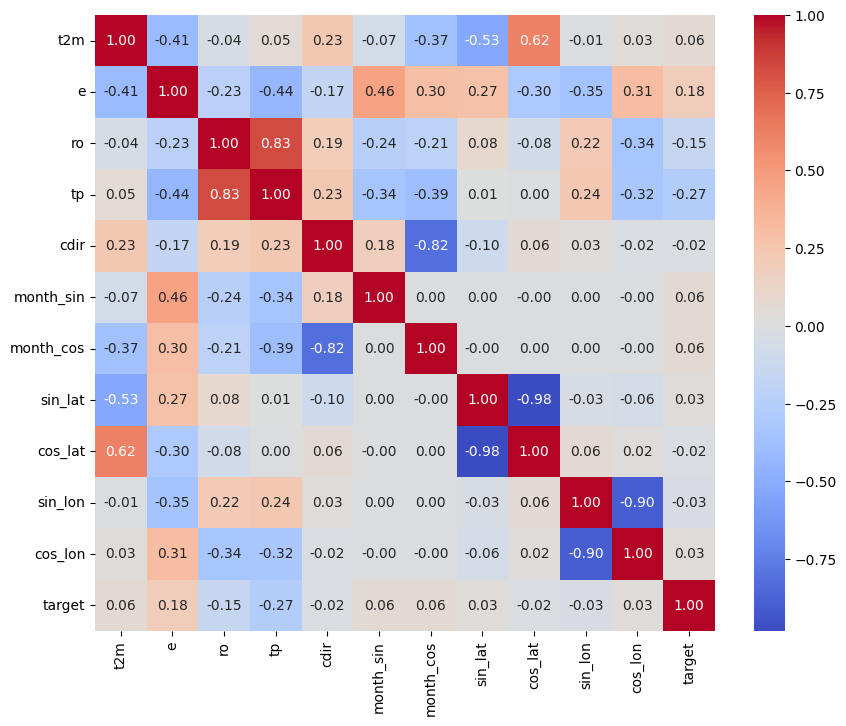

In [25]:
# Set the figure size (width, height) in inches
plt.figure(figsize=(10, 8))

# Create the heatmap
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")

# Show the plot
plt.show()

In [38]:
df.drop(['cos_lat', 'cos_lon', 'month_cos'], axis=1, inplace=True)

In [27]:
df.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
t2m,3395288.0,-0.000026,1.000221,-5.107706,-0.190033,2.645095e-01,0.559593,1.572942
e,3395288.0,-0.000205,0.999627,-4.511131,-0.852382,-1.633060e-02,0.778403,1.836827
ro,3395288.0,0.000206,1.000245,-0.380768,-0.376317,-3.412037e-01,-0.136461,22.860512
tp,3395288.0,0.000096,0.999955,-0.648615,-0.620609,-4.296609e-01,0.227930,16.722975
cdir,3395288.0,0.000462,0.999764,-2.880231,-0.721101,9.931111e-02,0.745788,3.168253
month_sin,3395288.0,-0.000003,0.707200,-1.000000,-0.866025,1.224647e-16,0.866025,1.000000
sin_lat,3395288.0,0.395020,0.094937,0.143493,0.337917,4.027467e-01,0.453990,0.601815
sin_lon,3395288.0,0.978076,0.014961,0.928810,0.968148,9.790455e-01,0.990866,1.000000
target,3395288.0,0.802258,1.206403,0.000000,0.000000,0.000000e+00,1.000000,4.000000


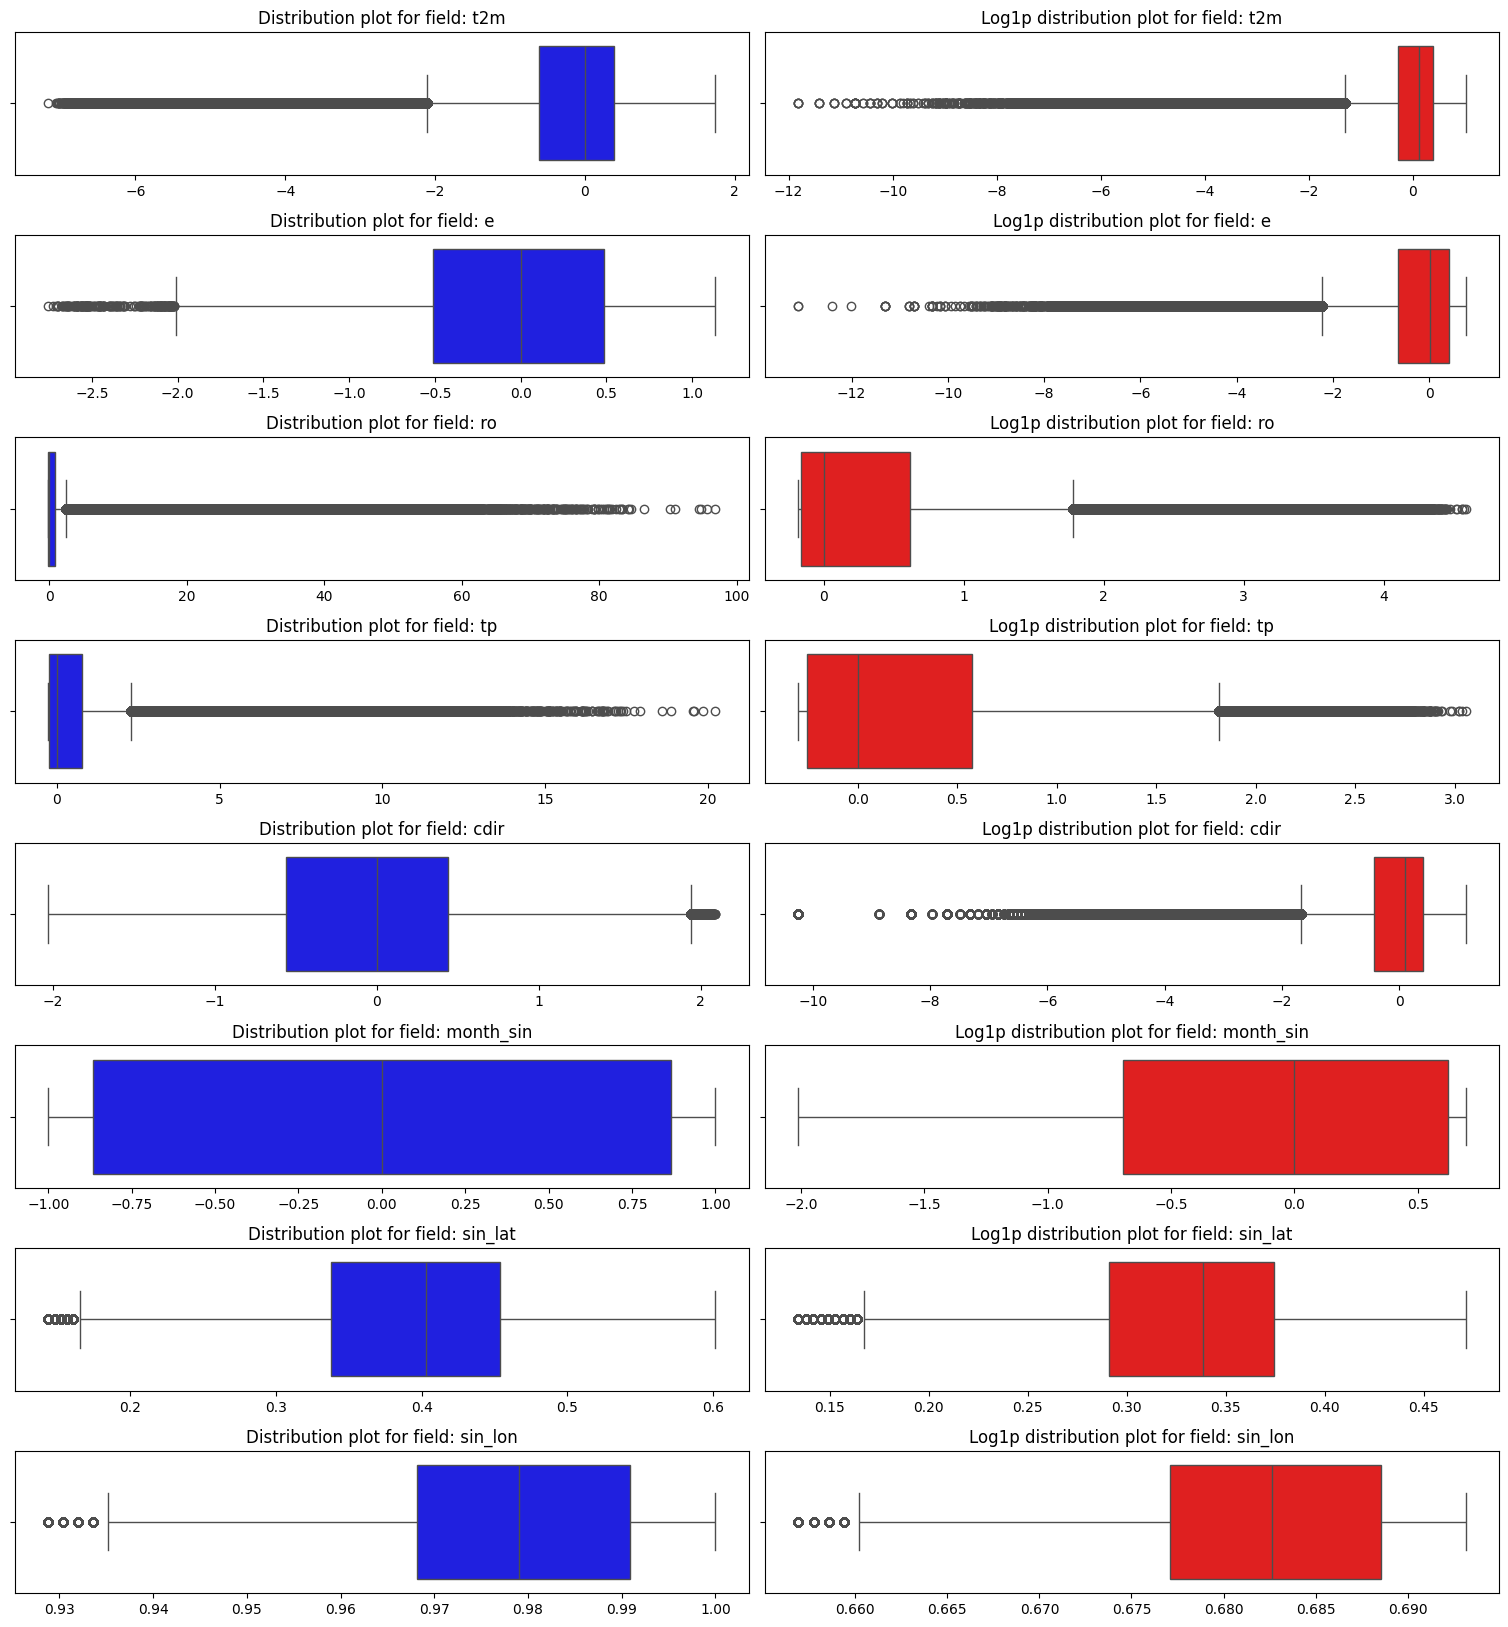

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the figure size
plt.figure(figsize=(15, 20))

# Get numeric columns excluding the target
numeric_cols = df.drop('target', axis=1).select_dtypes(include='number').columns

for i, c in enumerate(numeric_cols):
    # Original Data Boxplot (Horizontal)
    plt.subplot(10, 2, i * 2 + 1)
    sns.boxplot(x=df[c], color='blue')  # Explicitly set x for horizontal orientation
    plt.title('Distribution plot for field: ' + c)
    plt.xlabel('')
    
    # Log Transformed Data Boxplot (Horizontal)
    plt.subplot(10, 2, i * 2 + 2)
    sns.boxplot(x=df[c].apply('log1p'), color='red')  # Explicitly set x for horizontal orientation
    plt.title('Log1p distribution plot for field: ' + c)
    plt.xlabel('')

# Call tight_layout once at the end to prevent overlapping
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=1.0)
plt.show()

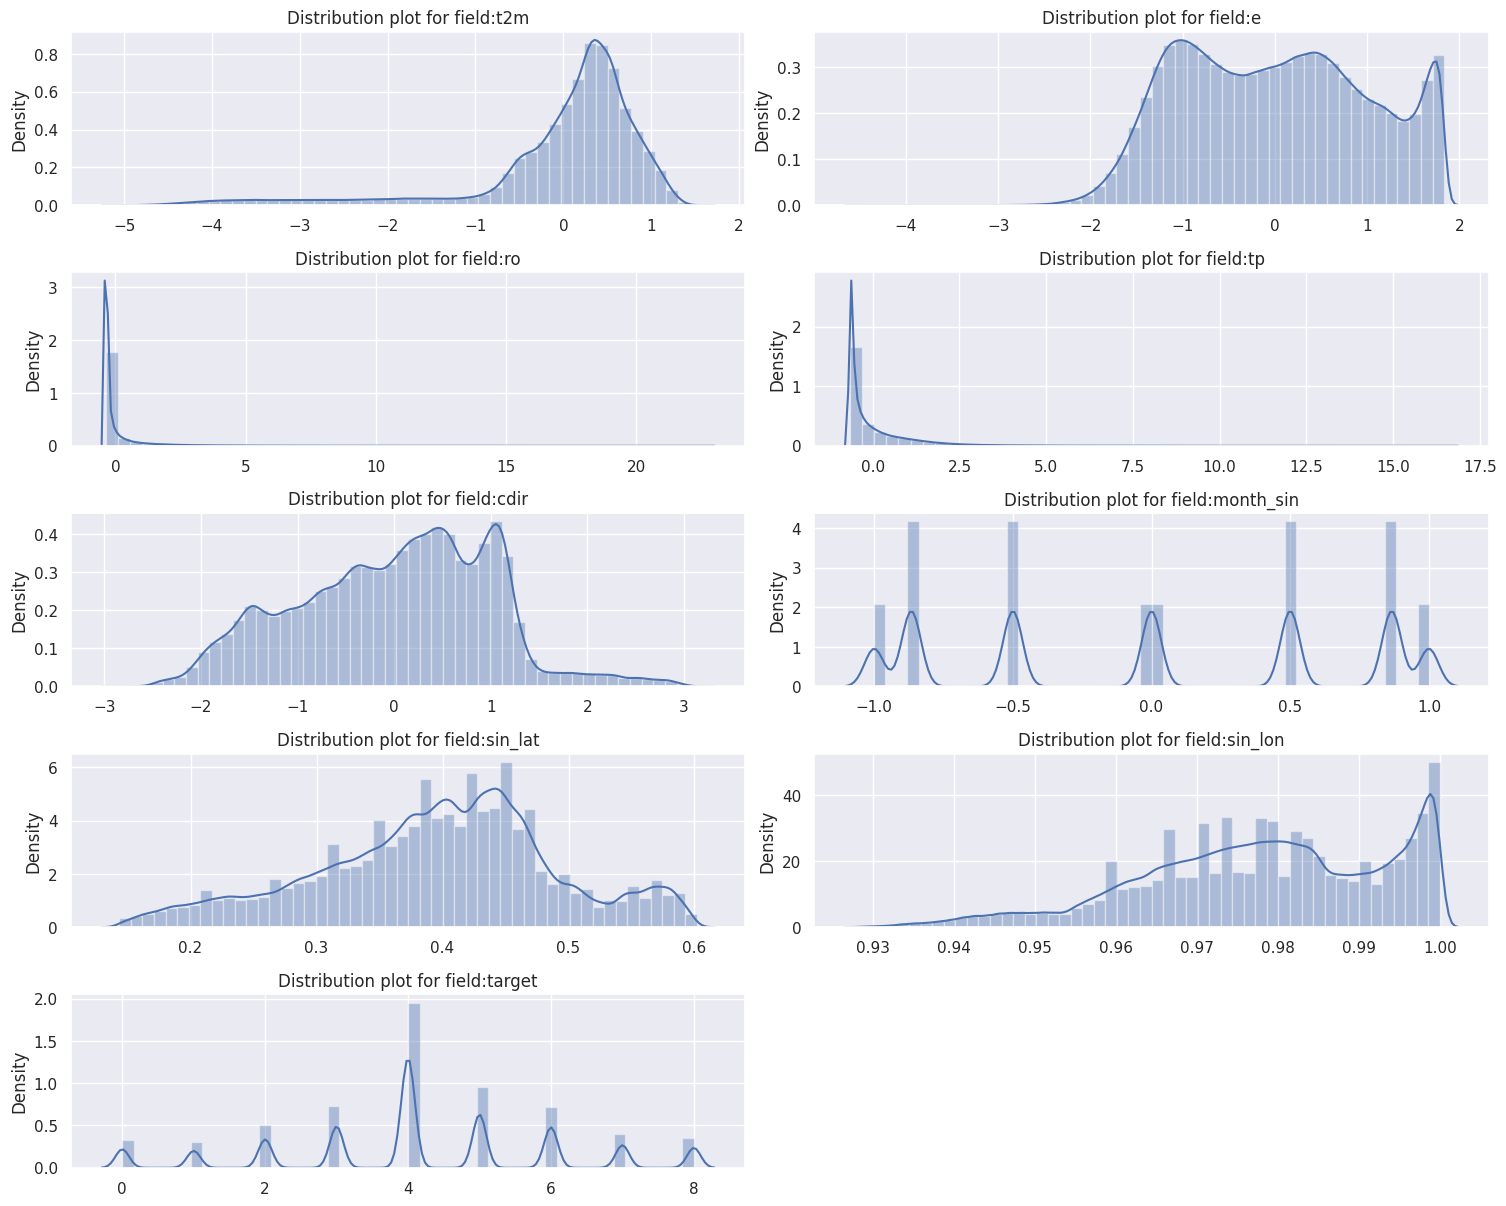

In [22]:
plt.figure(figsize=(15, 12))

for i, c in enumerate(df.select_dtypes(include='number').columns):
    plt.subplot(5,2,i+1)
    sns.distplot(df[c])
    plt.title('Distribution plot for field:' + c)
    plt.xlabel('')
    plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=1.0)

In [41]:
import pandas as pd

# 1. Determine the number of samples per class
# We'll take the count of the smallest class to ensure perfect balance
min_class_size = df['target'].value_counts().min()

print(f"Sampling {min_class_size} rows from each of the unique classes.")

# 2. Perform the balanced sampling
df_balanced = (
    df.groupby('target', group_keys=False)
    .apply(lambda x: x.sample(n=min_class_size, random_state=42))
)

# 3. Shuffle the final dataframe 
# (groupby/apply keeps classes together, shuffling is better for training)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# 4. Verify the results
print(df_balanced['target'].value_counts())

Sampling 192546 rows from each of the unique classes.
target
0.0    192546
1.0    192546
3.0    192546
2.0    192546
4.0    192546
Name: count, dtype: int64


In [42]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df_balanced.drop('target', axis=1), df_balanced['target'], test_size=0.25, random_state=123)

print('Train values shape:', X_train.shape)
print('Test values shape:', X_test.shape)
print('Train target shape:', y_train.shape)
print('Test target shape:', y_test.shape)

Train values shape: (722047, 8)
Test values shape: (240683, 8)
Train target shape: (722047,)
Test target shape: (240683,)


## Model Selection

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [ ]:
model = MLPClassifier(
    hidden_layer_sizes=(100, 50), # Two layers often capture patterns better than one
    activation='relu',            # Standard for deep learning
    solver='adam',                # Efficient for most dataset sizes
    alpha=0.001,                  # Slight regularization to prevent overfitting
    batch_size='auto',            # Let the model determine batch size based on data
    learning_rate_init=0.001,     # A standard starting point for Adam
    max_iter=500,                 # Extra iterations to ensure convergence
    early_stopping=True,          # Stops training if the model stops improving
    random_state=42               # Ensures reproducibility
)

In [45]:
# Neural nets
model = MLPClassifier()
model = MLPClassifier(
    hidden_layer_sizes=(100, 50), # Two layers often capture patterns better than one
    activation='relu',            # Standard for deep learning
    solver='adam',                # Efficient for most dataset sizes
    alpha=0.001,                  # Slight regularization to prevent overfitting
    batch_size='auto',            # Let the model determine batch size based on data
    learning_rate_init=0.001,     # A standard starting point for Adam
    max_iter=500,                 # Extra iterations to ensure convergence
    early_stopping=True,          # Stops training if the model stops improving
    random_state=42               # Ensures reproducibility
)
model.fit(X_train, y_train)
y_train_hat = model.predict(X_train)
y_test_hat = model.predict(X_test)

# print(model)
print('Train performance')
print('-------------------------------------------------------')
print(classification_report(y_train, y_train_hat))

print('Test performance')
print('-------------------------------------------------------')
print(classification_report(y_test, y_test_hat))


Train performance
-------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.73      0.77      0.75    144535
         1.0       0.44      0.55      0.49    144473
         2.0       0.42      0.31      0.36    144246
         3.0       0.45      0.36      0.40    144647
         4.0       0.61      0.69      0.65    144146

    accuracy                           0.54    722047
   macro avg       0.53      0.54      0.53    722047
weighted avg       0.53      0.54      0.53    722047

Test performance
-------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.73      0.77      0.75     48011
         1.0       0.44      0.55      0.49     48073
         2.0       0.42      0.31      0.35     48300
         3.0       0.45      0.36      0.40     47899
         4.0       0.61      0.69      0.65     48400

    accuracy                          

In [35]:
from xgboost import XGBClassifier

model = XGBClassifier(
        n_estimators=500,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1.0,
        tree_method='hist',
        device='cuda',
        # eval_metric='mlogloss'
    )
model.fit(X_train, y_train)
y_train_hat = model.predict(X_train)
y_test_hat = model.predict(X_test)

# print(model)
print('Train performance')
print('-------------------------------------------------------')
print(classification_report(y_train, y_train_hat))

print('Test performance')
print('-------------------------------------------------------')
print(classification_report(y_test, y_test_hat))

Train performance
-------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.84      0.85      0.84    144535
         1.0       0.58      0.68      0.63    144473
         2.0       0.62      0.43      0.51    144246
         3.0       0.59      0.59      0.59    144647
         4.0       0.71      0.81      0.76    144146

    accuracy                           0.67    722047
   macro avg       0.67      0.67      0.67    722047
weighted avg       0.67      0.67      0.67    722047

Test performance
-------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.82      0.83      0.82     48011
         1.0       0.54      0.63      0.58     48073
         2.0       0.54      0.37      0.44     48300
         3.0       0.53      0.54      0.54     47899
         4.0       0.69      0.78      0.73     48400

    accuracy                          

In [28]:
# Logistic Regression
model = LogisticRegression()
model.fit(X_train, y_train)
y_train_hat = model.predict(X_train)
y_test_hat = model.predict(X_test)

print(model)
print('Train performance')
print('-------------------------------------------------------')
print(classification_report(y_train, y_train_hat))


LogisticRegression()
Train performance
-------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.27      0.07      0.11    134292
         1.0       0.21      0.00      0.00    122739
         2.0       0.23      0.03      0.05    205512
         3.0       0.27      0.00      0.00    299713
         4.0       0.32      0.98      0.48    794910
         5.0       0.17      0.00      0.00    387200
         6.0       0.17      0.01      0.01    293979
         7.0       0.14      0.00      0.00    163709
         8.0       0.17      0.02      0.04    144412

    accuracy                           0.31   2546466
   macro avg       0.22      0.12      0.08   2546466
weighted avg       0.24      0.31      0.16   2546466



In [ ]:
# Support Vector Machines
model = SVC()
model.fit(X_train, y_train)
y_train_hat = model.predict(X_train)
y_test_hat = model.predict(X_test)

print(model)
print('Train performance')
print('-------------------------------------------------------')
print(classification_report(y_train, y_train_hat))

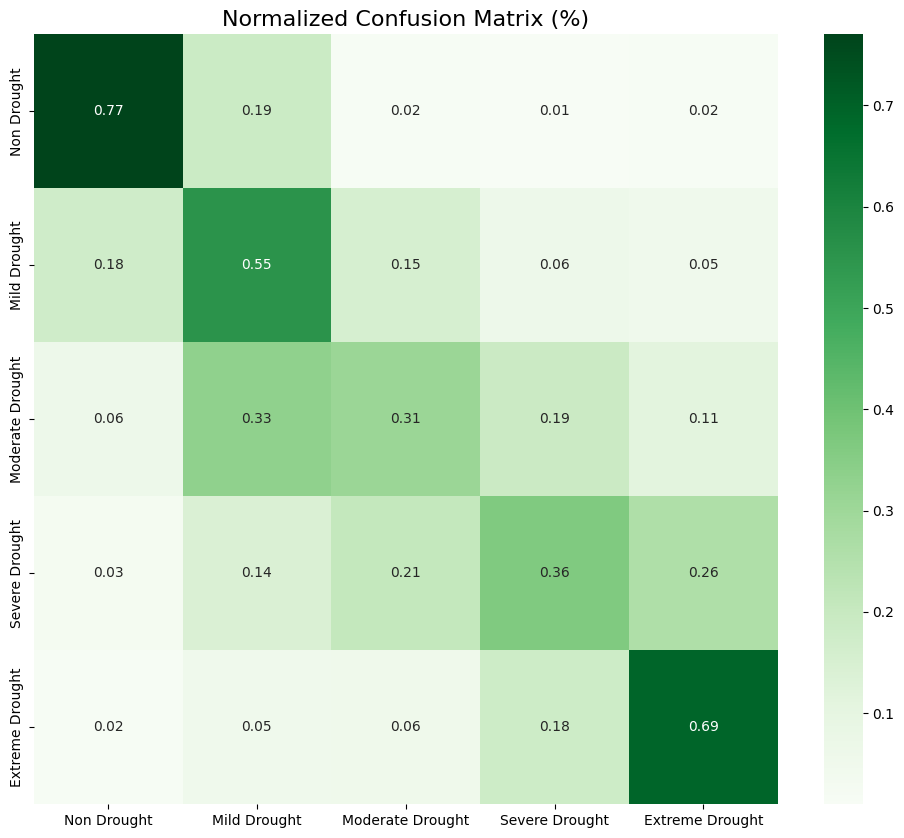

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Define your class labels (matching your 9-category logic)
class_names = [
     
    'Non Drought', 'Mild Drought', 'Moderate Drought', 'Severe Drought', 'Extreme Drought'
]

# 2. Generate the confusion matrix
# Replace 'y_test' and 'y_pred' with your actual test labels and model predictions
cm = confusion_matrix(y_test, y_test_hat)

# Compute normalized matrix (percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Greens', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.title('Normalized Confusion Matrix (%)', fontsize=16)
plt.show()

# Model Devolopment

In [9]:
df['month_sin'].unique()

array([ 5.00000000e-01,  8.66025404e-01,  1.00000000e+00,  8.66025404e-01,
        1.22464680e-16, -5.00000000e-01, -8.66025404e-01, -1.00000000e+00,
       -8.66025404e-01, -5.00000000e-01, -2.44929360e-16])

In [72]:
TrainData = pd.read_csv(r'/mnt/ssd2/animesh/VSCode/DroughtXAIPred/Data/TrainData.csv')

ValidData = pd.read_csv(r'/mnt/ssd2/animesh/VSCode/DroughtXAIPred/Data/ValidData.csv')

TestData = pd.read_csv(r'/mnt/ssd2/animesh/VSCode/DroughtXAIPred/Data/TestData.csv')


In [61]:
# fuction to create more features
def create_features(df):
    # create ratio features
    # df['t2m_e_ratio'] = df['t2m'] / (df['e'] + 1e-6)  # add small value to avoid division by zero
    # df['t2m_cdir_ratio'] = df['t2m'] / (df['cdir'] + 1e-6)
    # df['ro_tp_ratio'] = df['ro'] / (df['tp'] + 1e-6)
    # df['tp_cdir_ratio'] = df['tp'] / (df['cdir'] + 1e-6)
    df['t2m_sin_lat_ratio'] = df['t2m'] / (df['sin_lat'] + 1e-6)
    df['t2m_cos_lat_ratio'] = df['t2m'] / (df['cos_lat'] + 1e-6)
    df['cdir_sin_lat_ratio'] = df['cdir'] / (df['sin_lat'] + 1e-6)
    df['cdir_cos_lat_ratio'] = df['cdir'] / (df['cos_lat'] + 1e-6)
    df['tp_sin_lat_ratio'] = df['tp'] / (df['sin_lat'] + 1e-6)
    df['tp_cos_lat_ratio'] = df['tp'] / (df['cos_lat'] + 1e-6)
    
    # create interaction features 
    # df['t2m_cdir_interaction'] = df['t2m'] * df['cdir']
    # df['t2m_tp_interaction'] = df['t2m'] * df['tp']
    # df['cdir_tp_interaction'] = df['cdir'] * df['tp']
    # df['t2m_lat_interaction'] = (df['t2m'] * df['sin_lat']) - (df['t2m'] * df['cos_lat'])
    # df['cdir_lat_interaction'] = (df['cdir'] * df['sin_lat']) - (df['cdir'] * df['cos_lat'])
    df['tp_lat_interaction'] = (df['tp'] * df['sin_lat']) - (df['tp'] * df['cos_lat'])
    df['t2m_lon_interaction'] = (df['t2m'] * df['sin_lon']) - (df['t2m'] * df['cos_lon'])
    df['cdir_lon_interaction'] = (df['cdir'] * df['sin_lon']) - (df['cdir'] * df['cos_lon'])
    df['tp_lon_interaction'] = (df['tp'] * df['sin_lon']) - (df['tp'] * df['cos_lon'])
      
    

    df['lat_lon_interaction'] = (df['sin_lat'] * df['cos_lon']) - (df['cos_lat'] * df['sin_lon'])
    return df
TrainData = create_features(TrainData)
ValidData = create_features(ValidData)
TestData = create_features(TestData)

In [58]:
TrainData.head()

,t2m,e,ro,tp,cdir,month_sin,month_cos,sin_lat,cos_lat,sin_lon,...,t2m_cdir_ratio,ro_tp_ratio,tp_cdir_ratio,t2m_sin_lat_ratio,t2m_cos_lat_ratio,cdir_sin_lat_ratio,cdir_cos_lat_ratio,tp_sin_lat_ratio,tp_cos_lat_ratio,lat_lon_interaction
0,-4.307594,1.791817,-0.375822,-0.412930,-1.962209,0.5,0.866025,0.601815,0.798636,0.964787,...,2.195279,0.910137,0.210442,-7.157660,-5.393686,-3.260480,-2.456949,-0.686140,-0.517044,-0.612217
1,-4.135662,1.766785,-0.375822,-0.514406,-1.972244,0.5,0.866025,0.601815,0.798636,0.967046,...,2.096933,0.730596,0.260823,-6.871970,-5.178403,-3.277154,-2.469514,-0.854756,-0.644105,-0.619094
2,-4.228733,1.808788,-0.380768,-0.256534,-1.955519,0.5,0.866025,0.598325,0.801254,0.961262,...,2.162461,1.484282,0.131185,-7.067611,-5.277638,-3.268320,-2.440571,-0.428753,-0.320166,-0.605294
3,-4.364609,1.817274,-0.380768,-0.181610,-1.946093,0.5,0.866025,0.598325,0.801254,0.962455,...,2.242756,2.096638,0.093320,-7.294706,-5.447218,-3.252565,-2.428806,-0.303530,-0.226657,-0.608761
4,-4.325001,1.817698,-0.380768,-0.220527,-1.935146,0.5,0.866025,0.598325,0.801254,0.963630,...,2.234975,1.726635,0.113959,-7.228507,-5.397784,-3.234269,-2.415144,-0.368573,-0.275227,-0.612217


array([[<Axes: title={'center': 't2m'}>, <Axes: title={'center': 'e'}>,
        <Axes: title={'center': 'ro'}>, <Axes: title={'center': 'tp'}>,
        <Axes: title={'center': 'cdir'}>],
       [<Axes: title={'center': 'month_sin'}>,
        <Axes: title={'center': 'month_cos'}>,
        <Axes: title={'center': 'sin_lat'}>,
        <Axes: title={'center': 'cos_lat'}>,
        <Axes: title={'center': 'sin_lon'}>],
       [<Axes: title={'center': 'cos_lon'}>,
        <Axes: title={'center': 'Target'}>,
        <Axes: title={'center': 't2m_sin_lat_ratio'}>,
        <Axes: title={'center': 't2m_cos_lat_ratio'}>,
        <Axes: title={'center': 'cdir_sin_lat_ratio'}>],
       [<Axes: title={'center': 'cdir_cos_lat_ratio'}>,
        <Axes: title={'center': 'tp_sin_lat_ratio'}>,
        <Axes: title={'center': 'tp_cos_lat_ratio'}>,
        <Axes: title={'center': 'tp_lat_interaction'}>,
        <Axes: title={'center': 't2m_lon_interaction'}>],
       [<Axes: title={'center': 'cdir_lon_interac

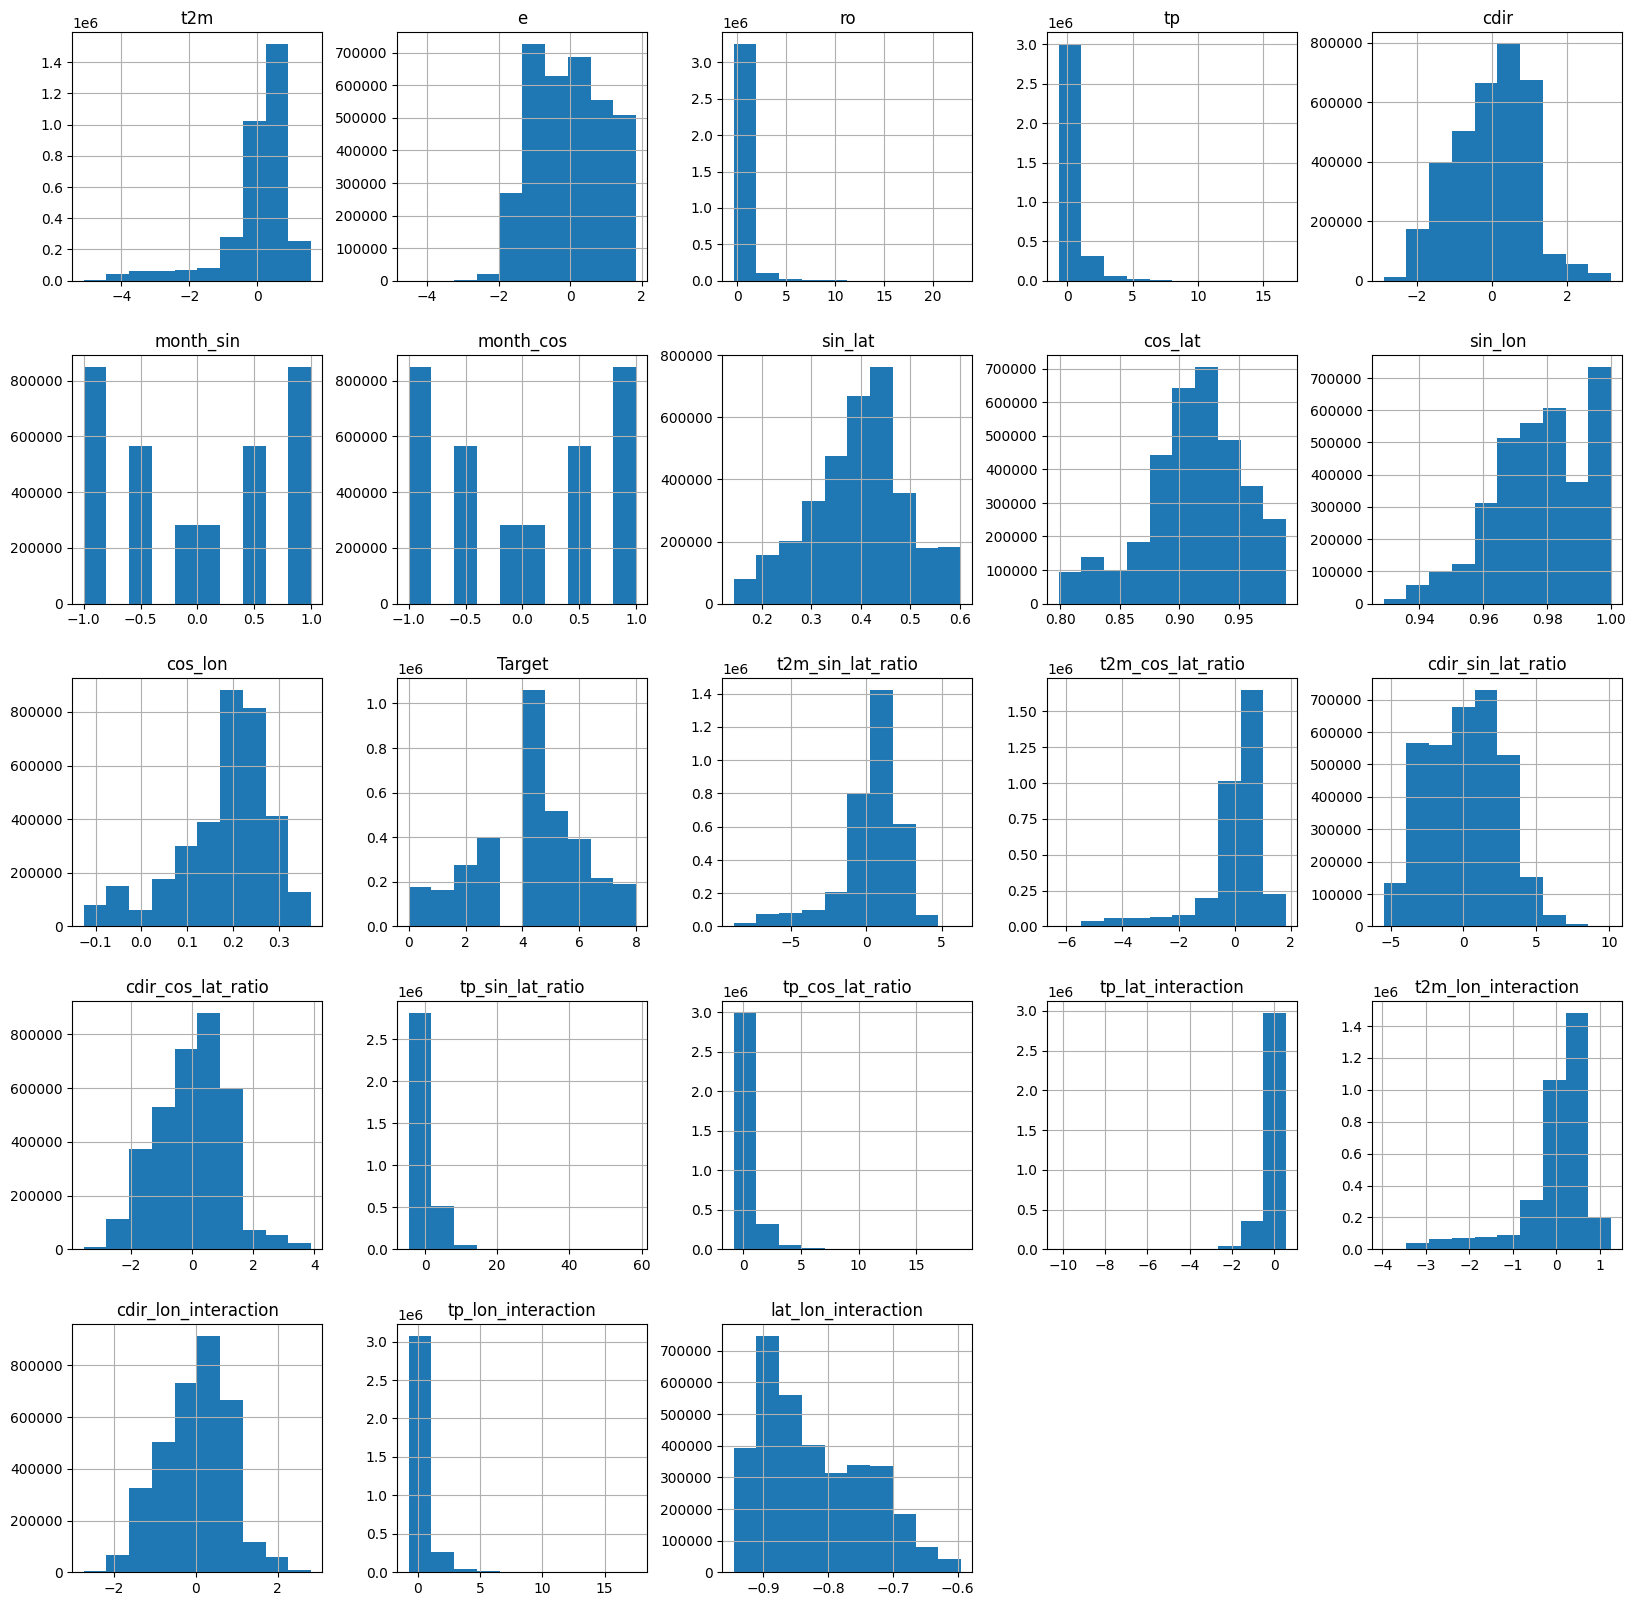

In [62]:
warnings.filterwarnings("ignore")
TrainData.hist(figsize=(20, 20))

In [63]:
Xtr, ytr = TrainData.drop(['Target'], axis=1).values, TrainData['Target'].values
Xva, yva = ValidData.drop(['Target'], axis=1).values, ValidData['Target'].values
Xte, yte = TestData.drop(['Target'], axis=1).values, TestData['Target'].values

In [68]:
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier


In [ ]:
model = XGBClassifier(
        n_estimators=500,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1.0,
        tree_method='hist',
        device='cuda',
        # eval_metric='mlogloss'
    )


In [69]:
model = MLPClassifier()

In [8]:
from sklearn.metrics import accuracy_score, f1_score

In [70]:
model.fit(Xtr, ytr)
        
# 2. Predict on validation data
val_preds = model.predict(Xva)
        
# 3. Calculate Metrics
# Using 'macro' F1 because you have 9 classes; it treats all classes equally
val_acc = accuracy_score(yva, val_preds)
val_f1 = f1_score(yva, val_preds, average='macro')
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Validation F1 Score: {val_f1:.4f}")

Validation Accuracy: 0.5305
Validation F1 Score: 0.4319
